<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/CODIGO_DATASET_PESSOAS_500_CORRET%C3%8DSSIMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

# ============================================================
# 1. Ler o dataset já existente
# ============================================================

# Se já tiver feito upload na célula anterior, df_pessoas já existe.
# Se quiser garantir, pode ler de novo:
df_pessoas = pd.read_csv("/content/dataset_pessoas_500.csv")

print("Formato do dataset:", df_pessoas.shape)
print("Colunas:", df_pessoas.columns.tolist())
print(df_pessoas.head())

Formato do dataset: (500, 10)
Colunas: ['ID_Pessoa', 'Tempo_Tela_Diario', 'Idade', 'Geracao', 'Frequencia_Culto_Semana', 'Frequencia_Pequeno_Grupo', 'Indice_Exposicao_Digital', 'Indice_Comunhao', 'Risco_Ansiedade', 'Risco_Depressao']
   ID_Pessoa  Tempo_Tela_Diario  ...  Risco_Ansiedade  Risco_Depressao
0          1              4.494  ...            5.990            3.962
1          2             11.409  ...            7.714            4.458
2          3              8.784  ...            6.249            5.394
3          4              7.184  ...            6.126            3.712
4          5              1.872  ...            3.210            0.295

[5 rows x 10 columns]


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

# ============================================================
# 2. Preparar os dados
# ============================================================

feature_cols = [
    "Tempo_Tela_Diario",
    "Idade",
    "Geracao",
    "Frequencia_Culto_Semana",
    "Frequencia_Pequeno_Grupo",
    "Indice_Exposicao_Digital",
    "Indice_Comunhao",
]

X = df_pessoas[feature_cols].values
y = df_pessoas[["Risco_Ansiedade", "Risco_Depressao"]].values















In [4]:
# ============================================================
# 3. Dividir em treino e teste + normalizar
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# ============================================================
# 4. Definir a rede neural (MLP de regressão)
# ============================================================

n_features = X_train_scaled.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    # Saída com 2 neurônios: [Risco_Ansiedade, Risco_Depressao]
    layers.Dense(2, activation="linear"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 818 (3.20 KB)

 Trainable params: 818 (3.20 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ============================================================
# 5. Treinar o modelo
# ============================================================

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 28.0373 - mae: 4.7447 - val_loss: 29.1085 - val_mae: 4.9432
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23.5863 - mae: 4.2891 - val_loss: 23.8518 - val_mae: 4.3911
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18.9945 - mae: 3.8096 - val_loss: 18.3458 - val_mae: 3.7511
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.2958 - mae: 3.2479 - val_loss: 13.0623 - val_mae: 3.0827
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.0291 - mae: 2.6643 - val_loss: 8.8504 - val_mae: 2.4515
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.8067 - mae: 2.1326 - val_loss: 5.8367 - val_mae: 1.9259
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.6291 - mae: 1.7431 - val_loss: 4.0405 - val_mae: 1.6297
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3277 - mae: 1.4758 - val_loss: 3.0348 - val_mae: 1.4166
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.62

In [7]:
# ============================================================
# 6. Avaliar no conjunto de teste
# ============================================================

loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nLoss (MSE) no teste: {loss:.4f}")
print(f"MAE no teste: {mae:.4f}")



Loss (MSE) no teste: 1.3494
MAE no teste: 0.9339


In [8]:
# ============================================================
# 7. Fazer previsões para novos perfis (exemplos)
# ============================================================

# Exemplo: 2 perfis novos
novos_perfils = pd.DataFrame({
    "Tempo_Tela_Diario":        [10.0, 2.0],
    "Idade":                    [18,   45],
    "Geracao":                  [1,    3],   # 1 = Gen Z, 3 = Gen X
    "Frequencia_Culto_Semana":  [0,    2],
    "Frequencia_Pequeno_Grupo": [0,    1],
    "Indice_Exposicao_Digital": [9.5,  3.5],
    "Indice_Comunhao":          [1.0,  7.0],
})

X_novos = scaler.transform(novos_perfils[feature_cols].values)
preds = model.predict(X_novos)

for i, p in enumerate(preds):
    print(f"\n--- Perfil {i+1} ---")
    print(novos_perfils.iloc[i])
    print(f"Risco Ansiedade previsto: {p[0]:.2f}")
    print(f"Risco Depressao previsto: {p[1]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

--- Perfil 1 ---
Tempo_Tela_Diario           10.0
Idade                       18.0
Geracao                      1.0
Frequencia_Culto_Semana      0.0
Frequencia_Pequeno_Grupo     0.0
Indice_Exposicao_Digital     9.5
Indice_Comunhao              1.0
Name: 0, dtype: float64
Risco Ansiedade previsto: 10.60
Risco Depressao previsto: 9.60

--- Perfil 2 ---
Tempo_Tela_Diario            2.0
Idade                       45.0
Geracao                      3.0
Frequencia_Culto_Semana      2.0
Frequencia_Pequeno_Grupo     1.0
Indice_Exposicao_Digital     3.5
Indice_Comunhao              7.0
Name: 1, dtype: float64
Risco Ansiedade previsto: 3.37
Risco Depressao previsto: 1.99


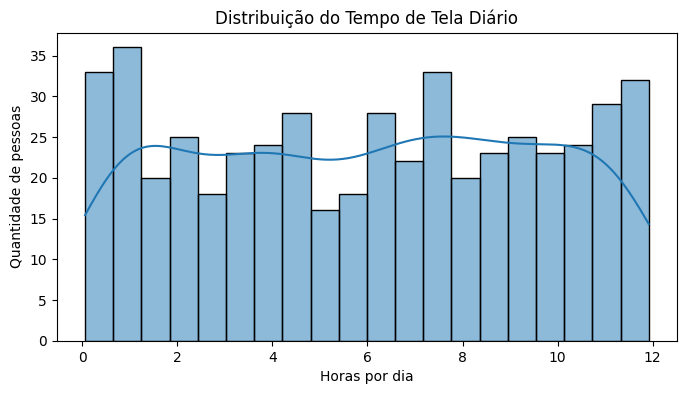

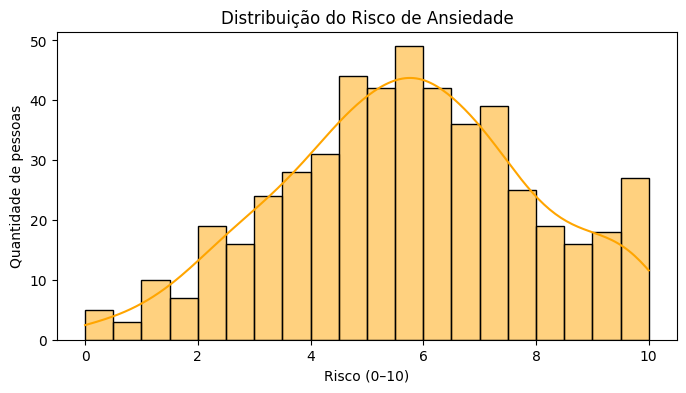

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exemplo: distribuição de Tempo_Tela_Diario
plt.figure(figsize=(8,4))
sns.histplot(df_pessoas["Tempo_Tela_Diario"], bins=20, kde=True)
plt.title("Distribuição do Tempo de Tela Diário")
plt.xlabel("Horas por dia")
plt.ylabel("Quantidade de pessoas")
plt.show()

# Exemplo: distribuição de Risco_Ansiedade
plt.figure(figsize=(8,4))
sns.histplot(df_pessoas["Risco_Ansiedade"], bins=20, kde=True, color="orange")
plt.title("Distribuição do Risco de Ansiedade")
plt.xlabel("Risco (0–10)")
plt.ylabel("Quantidade de pessoas")
plt.show()